In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Diabetes_dataset_2026_ver3 (1).csv', sep=';')
df['WaistCircumference'].fillna(df['WaistCircumference'].median(), inplace=True)

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Jumlah data training : {X_train.shape[0]}")
print(f"Jumlah data testing  : {X_test.shape[0]}")
print(f"Jumlah fitur         : {X_train.shape[1]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nStandarisasi selesai.")
print(f"Contoh mean : {X_train_scaled.mean(axis=0).round(4)[:3]}")
print(f"Contoh std  : {X_train_scaled.std(axis=0).round(4)[:3]}")

Jumlah data training : 6676
Jumlah data testing  : 2862
Jumlah fitur         : 16

Standarisasi selesai.
Contoh mean : [-0. -0.  0.]
Contoh std  : [1. 1. 1.]


/var/folders/2z/2pr2w1cx2xd8zkl50f5vf1640000gn/T/ipykernel_2728/3174880560.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['WaistCircumference'].fillna(df['WaistCircumference'].median(), inplace=True)


In [6]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

print("Model Naive Bayes berhasil dilatih!")
print(f"Kelas yang dipelajari : {nb_model.classes_}")
print(f"Jumlah fitur          : {nb_model.n_features_in_}")

Model Naive Bayes berhasil dilatih!
Kelas yang dipelajari : [0 1]
Jumlah fitur          : 16


====== Evaluasi Naive Bayes (Sebelum SMOTE) ======
Accuracy  : 0.9616
Precision : 1.0000
Recall    : 0.8866
F1-Score  : 0.9399

Confusion Matrix:
[[1892    0]
 [ 110  860]]

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetes (0)       0.95      1.00      0.97      1892
    Diabetes (1)       1.00      0.89      0.94       970

        accuracy                           0.96      2862
       macro avg       0.97      0.94      0.96      2862
    weighted avg       0.96      0.96      0.96      2862



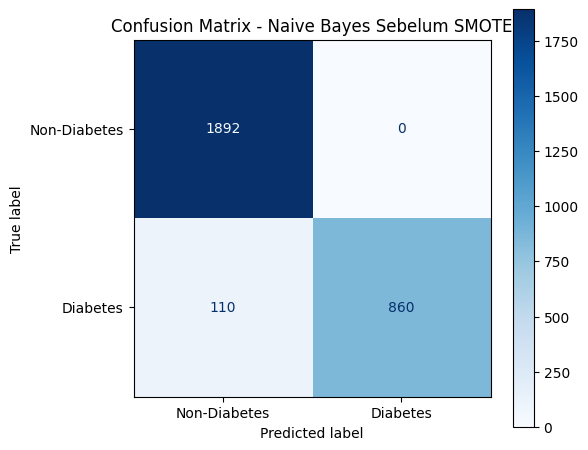

In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

y_pred_nb = nb_model.predict(X_test_scaled)

accuracy_nb  = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb    = recall_score(y_test, y_pred_nb)
f1_nb        = f1_score(y_test, y_pred_nb)

print("====== Evaluasi Naive Bayes (Sebelum SMOTE) ======")
print(f"Accuracy  : {accuracy_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"F1-Score  : {f1_nb:.4f}")

cm_before = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion Matrix:")
print(cm_before)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Non-Diabetes (0)', 'Diabetes (1)']))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_before, display_labels=['Non-Diabetes', 'Diabetes'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - Naive Bayes Sebelum SMOTE')
plt.tight_layout()
plt.savefig('cm_before_smote.png', dpi=150)
plt.show()

====== Distribusi Kelas Sebelum SMOTE ======
Kelas 0 (Non-Diabetes) : 4364
Kelas 1 (Diabetes)     : 2312
Rasio imbalance        : 1.89:1


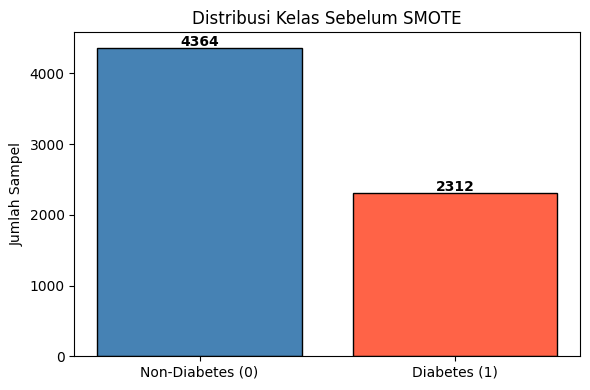

In [8]:
from collections import Counter
from imblearn.over_sampling import SMOTE

class_dist_before = Counter(y_train)
print("====== Distribusi Kelas Sebelum SMOTE ======")
print(f"Kelas 0 (Non-Diabetes) : {class_dist_before[0]}")
print(f"Kelas 1 (Diabetes)     : {class_dist_before[1]}")
print(f"Rasio imbalance        : {class_dist_before[0]/class_dist_before[1]:.2f}:1")

plt.figure(figsize=(6, 4))
bars = plt.bar(['Non-Diabetes (0)', 'Diabetes (1)'],
               [class_dist_before[0], class_dist_before[1]],
               color=['steelblue', 'tomato'], edgecolor='black')
for bar, val in zip(bars, [class_dist_before[0], class_dist_before[1]]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontweight='bold')
plt.title('Distribusi Kelas Sebelum SMOTE')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.savefig('distribusi_sebelum_smote.png', dpi=150)
plt.show()

/Users/falihaersa/Documents/DATMIN_MODUL 3/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


====== Distribusi Kelas Setelah SMOTE ======
Kelas 0 (Non-Diabetes) : 4364
Kelas 1 (Diabetes)     : 4364
Rasio                  : 1.00:1


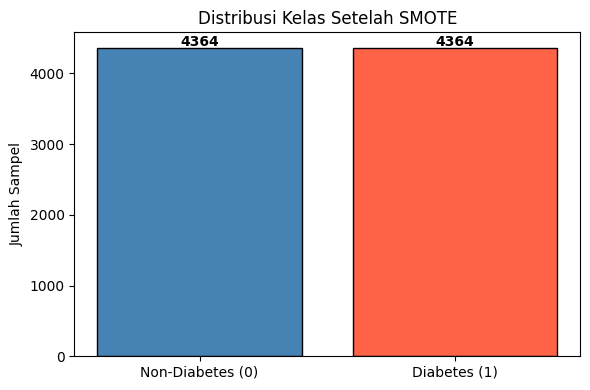

In [9]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

class_dist_after = Counter(y_train_smote)
print("====== Distribusi Kelas Setelah SMOTE ======")
print(f"Kelas 0 (Non-Diabetes) : {class_dist_after[0]}")
print(f"Kelas 1 (Diabetes)     : {class_dist_after[1]}")
print(f"Rasio                  : {class_dist_after[0]/class_dist_after[1]:.2f}:1")

plt.figure(figsize=(6, 4))
bars = plt.bar(['Non-Diabetes (0)', 'Diabetes (1)'],
               [class_dist_after[0], class_dist_after[1]],
               color=['steelblue', 'tomato'], edgecolor='black')
for bar, val in zip(bars, [class_dist_after[0], class_dist_after[1]]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontweight='bold')
plt.title('Distribusi Kelas Setelah SMOTE')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.savefig('distribusi_setelah_smote.png', dpi=150)
plt.show()

In [10]:
nb_smote = GaussianNB()
nb_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = nb_smote.predict(X_test_scaled)

accuracy_smote  = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote    = recall_score(y_test, y_pred_smote)
f1_smote        = f1_score(y_test, y_pred_smote)

print("====== Evaluasi Naive Bayes (Setelah SMOTE) ======")
print(f"Accuracy  : {accuracy_smote:.4f}")
print(f"Precision : {precision_smote:.4f}")
print(f"Recall    : {recall_smote:.4f}")
print(f"F1-Score  : {f1_smote:.4f}")
print()
print(classification_report(y_test, y_pred_smote, target_names=['Non-Diabetes (0)', 'Diabetes (1)']))

====== Evaluasi Naive Bayes (Setelah SMOTE) ======
Accuracy  : 0.9616
Precision : 1.0000
Recall    : 0.8866
F1-Score  : 0.9399

                  precision    recall  f1-score   support

Non-Diabetes (0)       0.95      1.00      0.97      1892
    Diabetes (1)       1.00      0.89      0.94       970

        accuracy                           0.96      2862
       macro avg       0.97      0.94      0.96      2862
    weighted avg       0.96      0.96      0.96      2862



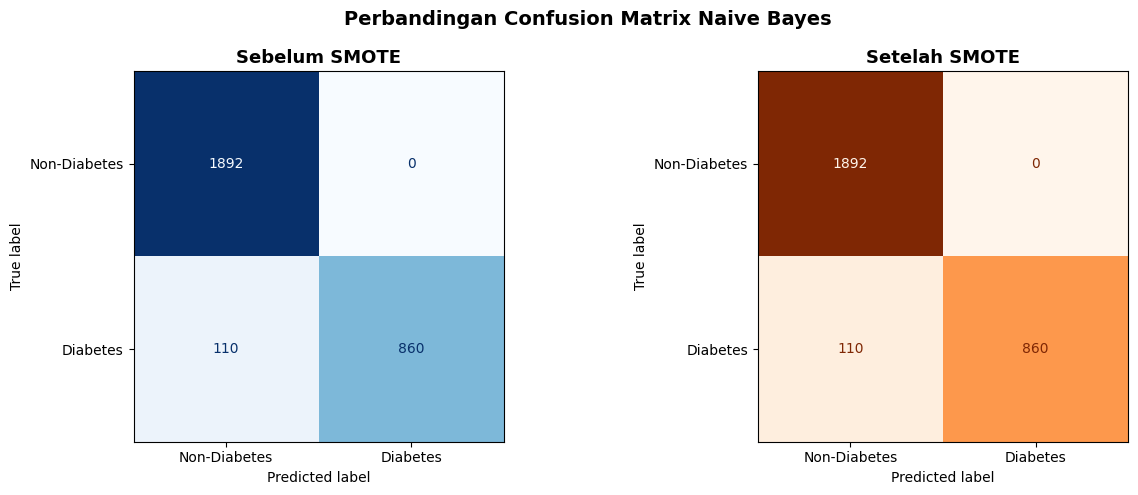


====== Perbandingan Metrik ======
Metrik         Sebelum SMOTE   Setelah SMOTE
--------------------------------------------
Accuracy              0.9616          0.9616
Precision             1.0000          1.0000
Recall                0.8866          0.8866
F1-Score              0.9399          0.9399


In [11]:
cm_after = confusion_matrix(y_test, y_pred_smote)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_before, display_labels=['Non-Diabetes', 'Diabetes'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Sebelum SMOTE', fontsize=13, fontweight='bold')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_after, display_labels=['Non-Diabetes', 'Diabetes'])
disp2.plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Setelah SMOTE', fontsize=13, fontweight='bold')

plt.suptitle('Perbandingan Confusion Matrix Naive Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('perbandingan_confusion_matrix.png', dpi=150)
plt.show()

print("\n====== Perbandingan Metrik ======")
print(f"{'Metrik':<12} {'Sebelum SMOTE':>15} {'Setelah SMOTE':>15}")
print("-" * 44)
print(f"{'Accuracy':<12} {accuracy_nb:>15.4f} {accuracy_smote:>15.4f}")
print(f"{'Precision':<12} {precision_nb:>15.4f} {precision_smote:>15.4f}")
print(f"{'Recall':<12} {recall_nb:>15.4f} {recall_smote:>15.4f}")
print(f"{'F1-Score':<12} {f1_nb:>15.4f} {f1_smote:>15.4f}")

In [12]:
import pickle
from sklearn.linear_model import LinearRegression

with open('nb_smote_model.pkl', 'wb') as f:
    pickle.dump(nb_smote, f)
with open('scaler_nb.pkl', 'wb') as f:
    pickle.dump(scaler, f)

X_lr = df.drop(columns=['Glucose', 'Outcome'])
y_lr = df['Glucose']
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.30, random_state=42)

scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)

lr_model = LinearRegression()
lr_model.fit(X_train_lr_scaled, y_train_lr)

with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('scaler_lr.pkl', 'wb') as f:
    pickle.dump(scaler_lr, f)

print("nb_smote_model.pkl tersimpan")
print("scaler_nb.pkl tersimpan")
print("lr_model.pkl tersimpan")
print("scaler_lr.pkl tersimpan")
print("\nSemua file .pkl berhasil dibuat!")

nb_smote_model.pkl tersimpan
scaler_nb.pkl tersimpan
lr_model.pkl tersimpan
scaler_lr.pkl tersimpan

Semua file .pkl berhasil dibuat!


In [14]:
app_code = '''import streamlit as st
import pickle
import numpy as np

with open('nb_smote_model.pkl', 'rb') as f:
    nb_model = pickle.load(f)
with open('scaler_nb.pkl', 'rb') as f:
    scaler_nb = pickle.load(f)
with open('lr_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)
with open('scaler_lr.pkl', 'rb') as f:
    scaler_lr = pickle.load(f)

st.set_page_config(page_title="RS Sehat Sentosa", page_icon="🏥", layout="wide")
st.sidebar.title("🏥 RS Sehat Sentosa")
st.sidebar.markdown("---")
halaman = st.sidebar.radio("Pilih Halaman:", [
    "🔬 Prediksi Glucose (Linear Regression)",
    "🩺 Klasifikasi Diabetes (Naive Bayes)"
])

if halaman == "🔬 Prediksi Glucose (Linear Regression)":
    st.title("🔬 Prediksi Kadar Glukosa Darah")
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        age            = st.number_input("Usia (Age)", min_value=0, max_value=120, value=45)
        pregnancies    = st.number_input("Jumlah Kehamilan", min_value=0, max_value=20, value=2)
        bmi            = st.number_input("BMI (x100)", min_value=0, max_value=9999, value=2800)
        blood_pressure = st.number_input("Blood Pressure (x10)", min_value=0, max_value=9999, value=750)
        hba1c          = st.number_input("HbA1c (x10)", min_value=0, max_value=999, value=55)
        ldl            = st.number_input("LDL (x10)", min_value=0, max_value=9999, value=1100)
        hdl            = st.number_input("HDL (x10)", min_value=0, max_value=9999, value=500)
    with col2:
        triglycerides       = st.number_input("Triglycerides (x10)", min_value=0, max_value=9999, value=700)
        waist_circumference = st.number_input("Lingkar Pinggang (x10)", min_value=0.0, max_value=2000.0, value=900.0)
        hip_circumference   = st.number_input("Lingkar Pinggul (x10)", min_value=0, max_value=9999, value=1000)
        whr                 = st.number_input("WHR (x100)", min_value=0, max_value=999, value=90)
        family_history      = st.selectbox("Riwayat Keluarga Diabetes", [0, 1], format_func=lambda x: "Ya" if x else "Tidak")
        diet_type           = st.selectbox("Tipe Diet", [0, 1, 2])
        hypertension        = st.selectbox("Hipertensi", [0, 1], format_func=lambda x: "Ya" if x else "Tidak")
        medication_use      = st.selectbox("Penggunaan Obat", [0, 1], format_func=lambda x: "Ya" if x else "Tidak")
    st.markdown("---")
    if st.button("🔍 Prediksi Glucose", use_container_width=True):
        input_lr = np.array([[age, pregnancies, bmi, blood_pressure, hba1c, ldl, hdl,
                              triglycerides, waist_circumference, hip_circumference,
                              whr, family_history, diet_type, hypertension, medication_use]])
        hasil = lr_model.predict(scaler_lr.transform(input_lr))[0]
        st.metric("Prediksi Kadar Glucose", f"{hasil:.0f}")
        if hasil > 1260:
            st.error("⚠️ Kadar Glucose TINGGI — Risiko Diabetes")
        elif hasil > 1000:
            st.warning("⚠️ Kadar Glucose SEDANG — Perlu Pemantauan")
        else:
            st.success("✅ Kadar Glucose NORMAL")
        st.info("Hasil ini bersifat prediktif. Keputusan medis tetap berada pada dokter.")

elif halaman == "🩺 Klasifikasi Diabetes (Naive Bayes)":
    st.title("🩺 Klasifikasi Risiko Diabetes")
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        age            = st.number_input("Usia (Age)", min_value=0, max_value=120, value=45)
        pregnancies    = st.number_input("Jumlah Kehamilan", min_value=0, max_value=20, value=2)
        bmi            = st.number_input("BMI (x100)", min_value=0, max_value=9999, value=2800)
        glucose        = st.number_input("Kadar Glucose (x10)", min_value=0, max_value=9999, value=1200)
        blood_pressure = st.number_input("Blood Pressure (x10)", min_value=0, max_value=9999, value=750)
        hba1c          = st.number_input("HbA1c (x10)", min_value=0, max_value=999, value=55)
        ldl            = st.number_input("LDL (x10)", min_value=0, max_value=9999, value=1100)
        hdl            = st.number_input("HDL (x10)", min_value=0, max_value=9999, value=500)
    with col2:
        triglycerides       = st.number_input("Triglycerides (x10)", min_value=0, max_value=9999, value=700)
        waist_circumference = st.number_input("Lingkar Pinggang (x10)", min_value=0.0, max_value=2000.0, value=900.0)
        hip_circumference   = st.number_input("Lingkar Pinggul (x10)", min_value=0, max_value=9999, value=1000)
        whr                 = st.number_input("WHR (x100)", min_value=0, max_value=999, value=90)
        family_history      = st.selectbox("Riwayat Keluarga Diabetes", [0, 1], format_func=lambda x: "Ya" if x else "Tidak")
        diet_type           = st.selectbox("Tipe Diet", [0, 1, 2])
        hypertension        = st.selectbox("Hipertensi", [0, 1], format_func=lambda x: "Ya" if x else "Tidak")
        medication_use      = st.selectbox("Penggunaan Obat", [0, 1], format_func=lambda x: "Ya" if x else "Tidak")
    st.markdown("---")
    if st.button("🔍 Klasifikasi Diabetes", use_container_width=True):
        input_nb = np.array([[age, pregnancies, bmi, glucose, blood_pressure, hba1c,
                              ldl, hdl, triglycerides, waist_circumference,
                              hip_circumference, whr, family_history, diet_type,
                              hypertension, medication_use]])
        input_scaled = scaler_nb.transform(input_nb)
        hasil = nb_model.predict(input_scaled)[0]
        proba = nb_model.predict_proba(input_scaled)[0]
        col_r1, col_r2, col_r3 = st.columns(3)
        with col_r1:
            st.metric("Hasil Klasifikasi", "DIABETES" if hasil == 1 else "NON-DIABETES")
        with col_r2:
            st.metric("Prob. Non-Diabetes", f"{proba[0]*100:.1f}%")
        with col_r3:
            st.metric("Prob. Diabetes", f"{proba[1]*100:.1f}%")
        if hasil == 1:
            st.error("🚨 Pasien TERDETEKSI DIABETES — Segera lakukan pemeriksaan lanjutan!")
        else:
            st.success("✅ Pasien TIDAK TERDETEKSI DIABETES — Tetap jaga pola hidup sehat.")
        st.info("Hasil ini bersifat prediktif. Keputusan medis tetap berada pada dokter.")
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("app.py berhasil dibuat! Sekarang jalankan di terminal:")
print("streamlit run app.py")

app.py berhasil dibuat! Sekarang jalankan di terminal:
streamlit run app.py
